# Tinh chỉnh Mô hình Tree-based — Dự báo PM2.5 (t+24h)

Notebook này thực hiện **bước tinh chỉnh siêu tham số (Hyperparameter Tuning)** cho các mô hình cây quyết định, nhằm khắc phục tình trạng **Overfitting nghiêm trọng** quan sát được ở notebook `7_tree_baseline.ipynb` (train RMSE ≈ 4 vs test RMSE ≈ 20).

**Chiến lược:**
1. **Phân tích Overfitting** — Xác định nguyên nhân gốc rễ từ baseline.
2. **Không gian siêu tham số Regularization-First** — Tập trung vào các tham số kiểm soát độ phức tạp mô hình (`max_depth`, `min_samples_leaf`, `reg_alpha`, `reg_lambda`, `min_child_weight`).
3. **RandomizedSearchCV + TimeSeriesSplit** — Tìm kiếm ngẫu nhiên với Cross-Validation tôn trọng tính thời gian (không shuffle).
4. **Evaluation thống nhất** — Đánh giá trên tập val và test bằng RMSE, MAE, MAPE (µg/m³ gốc).
5. **Export** — Lưu mô hình tốt nhất và metrics để so sánh toàn diện.

**Đầu vào:** `modeling_fs/train_tree.csv`, `val_tree.csv`, `test_tree.csv`  
**Đầu ra:** `outputs/predictions/tuned_tree_preds.pkl`, `outputs/predictions/tuned_tree_metrics.csv`, figures

## 0. Setup & Load Data

In [1]:
import warnings
import pickle
import time
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 130

MODELING = Path("../data/processed/modeling_fs")
FIG_DIR  = Path("../outputs/figures")
PRED_DIR = Path("../outputs/predictions")
FIG_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "target_pm25_h24"
print("[OK] Setup hoàn tất.")

[OK] Setup hoàn tất.


In [2]:
def load_xy(path: Path):
    df = pd.read_csv(path, parse_dates=["datetime_local"])
    feat = [c for c in df.columns if c not in ("datetime_local", TARGET)]
    return df[feat], df[TARGET], df["datetime_local"]


def regression_metrics(y_true, y_pred):
    """Tính RMSE, MAE, MAPE trên thang µg/m³ gốc."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    eps  = 1e-6
    mask = np.abs(y_true) > eps
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}


train_X, train_y, train_dt = load_xy(MODELING / "train_tree.csv")
val_X,   val_y,   val_dt   = load_xy(MODELING / "val_tree.csv")
test_X,  test_y,  test_dt  = load_xy(MODELING / "test_tree.csv")

# Gộp train + val để fit cuối cùng (chỉ dùng sau khi chọn được tham số tốt nhất)
trainval_X = pd.concat([train_X, val_X], ignore_index=True)
trainval_y = pd.concat([train_y, val_y], ignore_index=True)

n_features = train_X.shape[1]
print(f"Train: {train_X.shape} | Val: {val_X.shape} | Test: {test_X.shape}")
print(f"Features ({n_features}): {list(train_X.columns[:5])} ...")

Train: (6383, 26) | Val: (2128, 26) | Test: (2128, 26)
Features (26): ['month', 'month_cos', 'pm25', 'pm25_lag_1', 'hours_since_last_rain'] ...


## 1. Phân tích Overfitting từ Baseline

Trước khi tuning, ta xác định **nguyên nhân chính** gây overfitting:
- RandomForest `max_depth=20` → cây quá sâu, học thuộc lòng tập train
- XGBoost/LightGBM `learning_rate` chưa đủ nhỏ, ít regularization (`reg_alpha=0`, `reg_lambda=1`)
- Không có giới hạn `min_samples_leaf` đủ lớn

**Mục tiêu tuning:** Giảm gap `train RMSE ↔ test RMSE` (hiện tại ~5x).

In [3]:
# Load kết quả baseline để so sánh cuối
baseline_metrics_path = PRED_DIR / "tree_model_metrics.csv"
if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)
    print("=== Baseline Metrics ===")
    display(baseline_df.pivot_table(index="model", columns="split", values="RMSE").round(2))
else:
    print("[WARN] Chưa có file baseline — hãy chạy notebook 7 trước.")
    baseline_df = pd.DataFrame()

=== Baseline Metrics ===


split,test,train,val
model,,,
LightGBM,20.38,4.80,15.01
RandomForest,21.12,4.21,14.63
XGBoost,20.00,3.99,15.15


## 2. Không gian Siêu tham số (Param Grids)

Thiết kế **tập trung vào Regularization** — không mở rộng thêm thành phần mà chấp nhận mô hình đơn giản hơn để tổng quát tốt hơn.

In [4]:
# ─────────────────────────────────────────────────────────
# Random Forest — Giảm max_depth, tăng min_samples_leaf
# ─────────────────────────────────────────────────────────
rf_param_dist = {
    "n_estimators":    [200, 300, 500],
    "max_depth":       [5, 7, 10, 12, None],   # None = unlimited (baseline=20)
    "min_samples_leaf":[4, 8, 16, 32],          # baseline=2 → quá nhỏ
    "max_features":    ["sqrt", "log2", 0.5, 0.7],
    "min_impurity_decrease": [0.0, 0.01, 0.05],
}

# ─────────────────────────────────────────────────────────
# XGBoost — L1/L2, max_depth, subsample, colsample
# ─────────────────────────────────────────────────────────
xgb_param_dist = {
    "n_estimators":     [300, 500, 800],
    "max_depth":        [3, 4, 5, 6],           # baseline=6
    "learning_rate":    [0.01, 0.03, 0.05, 0.08],
    "subsample":        [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [3, 5, 10, 20],         # Tăng để giảm overfit
    "reg_alpha":        [0.0, 0.1, 0.5, 1.0],   # L1
    "reg_lambda":       [1.0, 2.0, 5.0, 10.0],  # L2
    "gamma":            [0.0, 0.1, 0.5, 1.0],   # Min loss reduction to split
}

# ─────────────────────────────────────────────────────────
# LightGBM — num_leaves, min_child_samples, reg
# ─────────────────────────────────────────────────────────
lgb_param_dist = {
    "n_estimators":        [300, 500, 800],
    "num_leaves":          [15, 31, 47, 63],     # baseline=63 → thử nhỏ hơn
    "max_depth":           [4, 6, 8, -1],
    "learning_rate":       [0.01, 0.03, 0.05, 0.08],
    "subsample":           [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree":    [0.6, 0.7, 0.8, 0.9],
    "min_child_samples":   [10, 20, 50, 100],    # baseline thường=20
    "reg_alpha":           [0.0, 0.1, 0.5, 1.0],
    "reg_lambda":          [1.0, 2.0, 5.0, 10.0],
}

print("[OK] Param grids defined.")
print(f"  RF combinations (sample): {3*5*4*4*3} = 720")
print(f"  XGB combinations (sample): {3*4*4*4*4*4*4*4*4} = ~100k (search space)")
print(f"  LGB combinations (sample): similar")

[OK] Param grids defined.
  RF combinations (sample): 720 = 720
  XGB combinations (sample): 196608 = ~100k (search space)
  LGB combinations (sample): similar


## 3. Thiết lập TimeSeriesSplit CV

Dùng `TimeSeriesSplit` thay vì KFold thông thường để **tôn trọng tính nhân quả của chuỗi thời gian** — fold sau luôn dùng dữ liệu sau fold trước (không shuffle).

In [5]:
N_CV_SPLITS = 5
N_ITER      = 40     # Số lần thử ngẫu nhiên mỗi mô hình
SCORING     = "neg_root_mean_squared_error"

tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

# Minh họa cách CV chia train set
print(f"TimeSeriesSplit với {N_CV_SPLITS} folds trên train ({len(train_X)} rows):")
for i, (tr_idx, vl_idx) in enumerate(tscv.split(train_X)):
    print(f"  Fold {i+1}: train [{tr_idx[0]}–{tr_idx[-1]}] | val [{vl_idx[0]}–{vl_idx[-1]}]")

TimeSeriesSplit với 5 folds trên train (6383 rows):
  Fold 1: train [0–1067] | val [1068–2130]
  Fold 2: train [0–2130] | val [2131–3193]
  Fold 3: train [0–3193] | val [3194–4256]
  Fold 4: train [0–4256] | val [4257–5319]
  Fold 5: train [0–5319] | val [5320–6382]


## 4. Randomized Search — Random Forest

In [6]:
print("=" * 60)
print("[1/3] TUNING: RandomForest")
print("=" * 60)
t0 = time.time()

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=2)

rf_search = RandomizedSearchCV(
    estimator  = rf_base,
    param_distributions = rf_param_dist,
    n_iter     = N_ITER,
    scoring    = SCORING,
    cv         = tscv,
    refit      = True,   # Tự fit lại trên toàn bộ train với best params
    n_jobs     = 1,      # Tránh nested parallelism với RF (n_jobs=2 bên trong)
    verbose    = 1,
    random_state = RANDOM_STATE,
    return_train_score = False,
)

rf_search.fit(train_X, train_y)

elapsed = time.time() - t0
print(f"\n[RF] Hoàn tất sau {elapsed:.1f}s")
print(f"[RF] Best CV RMSE: {-rf_search.best_score_:.4f}")
print(f"[RF] Best params: {rf_search.best_params_}")

[1/3] TUNING: RandomForest
Fitting 5 folds for each of 40 candidates, totalling 200 fits

[RF] Hoàn tất sau 279.4s
[RF] Best CV RMSE: 14.5225
[RF] Best params: {'n_estimators': 500, 'min_samples_leaf': 8, 'min_impurity_decrease': 0.05, 'max_features': 0.5, 'max_depth': 5}


## 5. Randomized Search — XGBoost

In [7]:
print("=" * 60)
print("[2/3] TUNING: XGBoost")
print("=" * 60)
t0 = time.time()

xgb_base = XGBRegressor(
    tree_method  = "hist",
    device       = "cpu",
    random_state = RANDOM_STATE,
    n_jobs       = 2,
    verbosity    = 0,
)

xgb_search = RandomizedSearchCV(
    estimator  = xgb_base,
    param_distributions = xgb_param_dist,
    n_iter     = N_ITER,
    scoring    = SCORING,
    cv         = tscv,
    refit      = True,
    n_jobs     = 1,
    verbose    = 1,
    random_state = RANDOM_STATE,
    return_train_score = False,
)

xgb_search.fit(train_X, train_y)

elapsed = time.time() - t0
print(f"\n[XGB] Hoàn tất sau {elapsed:.1f}s")
print(f"[XGB] Best CV RMSE: {-xgb_search.best_score_:.4f}")
print(f"[XGB] Best params: {xgb_search.best_params_}")

[2/3] TUNING: XGBoost
Fitting 5 folds for each of 40 candidates, totalling 200 fits

[XGB] Hoàn tất sau 65.9s
[XGB] Best CV RMSE: 14.3082
[XGB] Best params: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1.0, 'colsample_bytree': 0.9}


## 6. Randomized Search — LightGBM

In [8]:
print("=" * 60)
print("[3/3] TUNING: LightGBM")
print("=" * 60)
t0 = time.time()

lgb_base = LGBMRegressor(
    random_state = RANDOM_STATE,
    n_jobs       = 2,
    verbose      = -1,
)

lgb_search = RandomizedSearchCV(
    estimator  = lgb_base,
    param_distributions = lgb_param_dist,
    n_iter     = N_ITER,
    scoring    = SCORING,
    cv         = tscv,
    refit      = True,
    n_jobs     = 1,
    verbose    = 1,
    random_state = RANDOM_STATE,
    return_train_score = False,
)

lgb_search.fit(train_X, train_y)

elapsed = time.time() - t0
print(f"\n[LGB] Hoàn tất sau {elapsed:.1f}s")
print(f"[LGB] Best CV RMSE: {-lgb_search.best_score_:.4f}")
print(f"[LGB] Best params: {lgb_search.best_params_}")

[3/3] TUNING: LightGBM
Fitting 5 folds for each of 40 candidates, totalling 200 fits

[LGB] Hoàn tất sau 51.4s
[LGB] Best CV RMSE: 14.4189
[LGB] Best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


## 7. Tổng hợp Best Params & Bước Refit Train+Val

Sau khi tìm được tham số tối ưu từ CV trên tập train, ta **re-fit với toàn bộ train+val** (`trainval_X`) để tận dụng nhiều dữ liệu hơn trước khi đánh giá cuối cùng trên test.

In [9]:
best_params_summary = {
    "RandomForest": rf_search.best_params_,
    "XGBoost":      xgb_search.best_params_,
    "LightGBM":     lgb_search.best_params_,
}

print("=" * 60)
print("BEST PARAMS SUMMARY")
print("=" * 60)
for name, params in best_params_summary.items():
    print(f"\n[{name}]")
    for k, v in sorted(params.items()):
        print(f"  {k:<25} = {v}")

BEST PARAMS SUMMARY

[RandomForest]
  max_depth                 = 5
  max_features              = 0.5
  min_impurity_decrease     = 0.05
  min_samples_leaf          = 8
  n_estimators              = 500

[XGBoost]
  colsample_bytree          = 0.9
  gamma                     = 1.0
  learning_rate             = 0.01
  max_depth                 = 3
  min_child_weight          = 10
  n_estimators              = 500
  reg_alpha                 = 0.0
  reg_lambda                = 5.0
  subsample                 = 0.9

[LightGBM]
  colsample_bytree          = 0.9
  learning_rate             = 0.01
  max_depth                 = -1
  min_child_samples         = 10
  n_estimators              = 300
  num_leaves                = 15
  reg_alpha                 = 1.0
  reg_lambda                = 5.0
  subsample                 = 0.8


In [10]:
# Re-fit trên toàn bộ Train + Val với best params
print("Re-fitting trên Train+Val với best params...")

rf_final = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=RANDOM_STATE, n_jobs=2
)
rf_final.fit(trainval_X, trainval_y)
print("[RF] Refit done")

xgb_final = XGBRegressor(
    **xgb_search.best_params_,
    tree_method="hist", device="cpu",
    random_state=RANDOM_STATE, n_jobs=2, verbosity=0
)
xgb_final.fit(trainval_X, trainval_y)
print("[XGB] Refit done")

lgb_final = LGBMRegressor(
    **lgb_search.best_params_,
    random_state=RANDOM_STATE, n_jobs=2, verbose=-1
)
lgb_final.fit(trainval_X, trainval_y)
print("[LGB] Refit done")

Re-fitting trên Train+Val với best params...
[RF] Refit done
[XGB] Refit done
[LGB] Refit done


## 8. Đánh giá Hiệu suất — Train / Val / Test

In [11]:
tuned_models = {
    "RF_Tuned":  rf_final,
    "XGB_Tuned": xgb_final,
    "LGB_Tuned": lgb_final,
}

# Dự báo trên từng split
preds = {}
for name, model in tuned_models.items():
    preds[name] = {
        "train":    model.predict(trainval_X),
        "val":      model.predict(val_X),
        "test":     model.predict(test_X),
    }

# Tổng hợp metrics
rows = []
for name, model in tuned_models.items():
    rows.append({"model": name, "split": "train", **regression_metrics(trainval_y, preds[name]["train"])})
    rows.append({"model": name, "split": "val",   **regression_metrics(val_y,      preds[name]["val"])})
    rows.append({"model": name, "split": "test",  **regression_metrics(test_y,     preds[name]["test"])})

tuned_metrics_df = pd.DataFrame(rows)

print("\n=== TUNED MODEL METRICS ===")
display(tuned_metrics_df.pivot_table(index="model", columns="split", values="RMSE").round(3))


=== TUNED MODEL METRICS ===


split,test,train,val
model,,,
LGB_Tuned,17.975,11.866,12.853
RF_Tuned,18.794,12.765,13.582
XGB_Tuned,17.731,12.353,13.068


In [12]:
# Xem full bảng metrics
display(tuned_metrics_df.round(3))

,model,split,RMSE,MAE,MAPE
0,RF_Tuned,train,12.765,8.825,34.746
1,RF_Tuned,val,13.582,10.079,44.175
2,RF_Tuned,test,18.794,13.388,38.718
3,XGB_Tuned,train,12.353,8.611,33.397
4,XGB_Tuned,val,13.068,9.642,41.611
5,XGB_Tuned,test,17.731,12.704,36.346
6,LGB_Tuned,train,11.866,8.446,33.163
7,LGB_Tuned,val,12.853,9.595,42.029
8,LGB_Tuned,test,17.975,12.898,36.865


## 9. So sánh Baseline vs Tuned

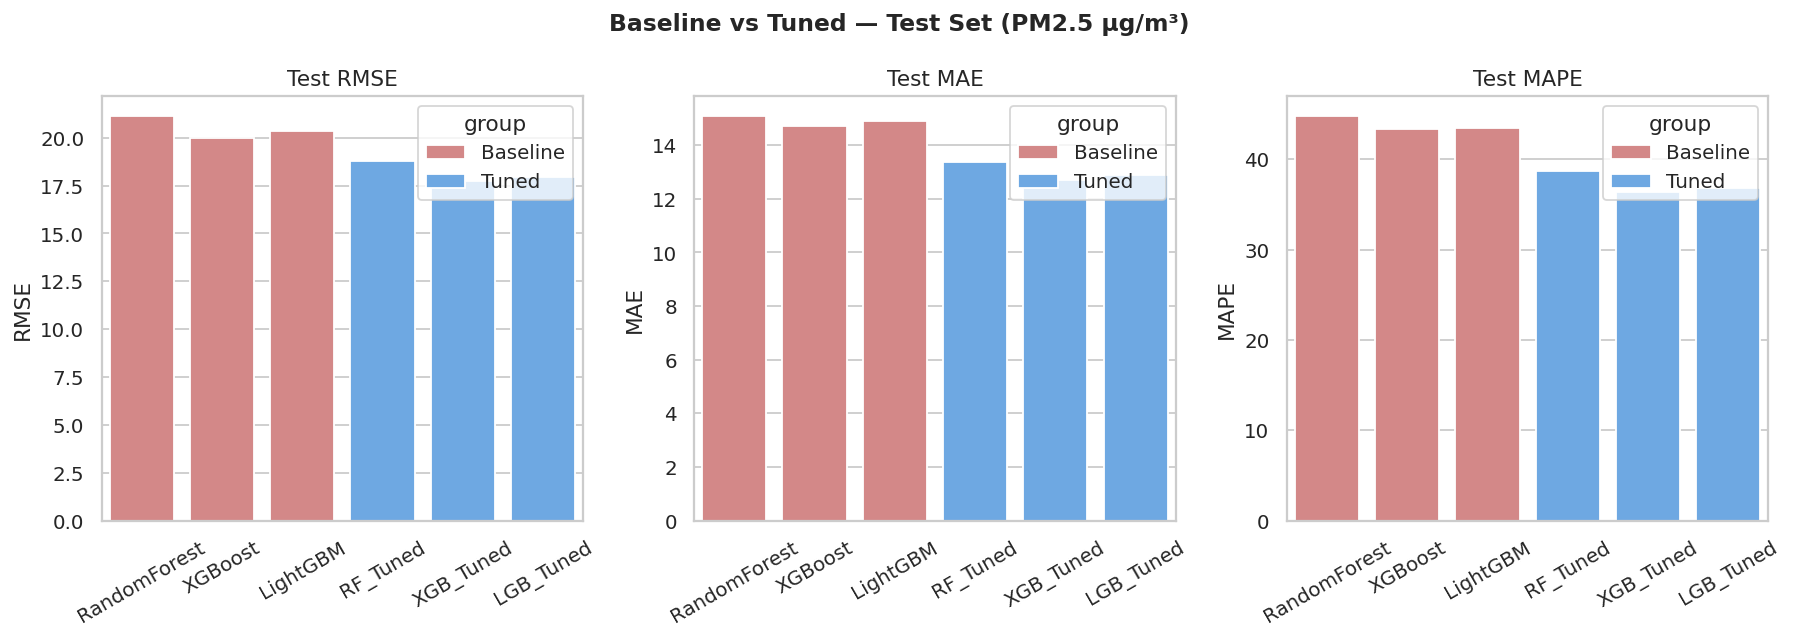

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tree_baseline_vs_tuned_test.png


In [13]:
if not baseline_df.empty:
    # Gộp baseline + tuned
    compare_df = pd.concat([
        baseline_df.assign(group="Baseline"),
        tuned_metrics_df.assign(group="Tuned")
    ], ignore_index=True)

    test_compare = compare_df[compare_df["split"] == "test"].copy()
    test_compare["label"] = test_compare["model"] + "\n(" + test_compare["group"] + ")"

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE"]):
        palette = {"Baseline": "#e07b7b", "Tuned": "#5ba8f5"}
        sns.barplot(
            data=test_compare, x="model", y=metric,
            hue="group", palette=palette, ax=ax,
            order=["RandomForest", "XGBoost", "LightGBM",
                   "RF_Tuned", "XGB_Tuned", "LGB_Tuned"],
        )
        ax.set_title(f"Test {metric}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle("Baseline vs Tuned — Test Set (PM2.5 µg/m³)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_compare = FIG_DIR / "tree_baseline_vs_tuned_test.png"
    fig.savefig(out_compare, dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", out_compare.resolve())
else:
    print("Không có baseline để so sánh.")

## 10. Overfitting Gap Analysis

=== Overfitting Gap (Test RMSE − Train RMSE) ===


,model,group,train_rmse,test_rmse,gap
0,RandomForest,Baseline,4.213,21.122,16.909
1,XGBoost,Baseline,3.995,19.996,16.001
2,LightGBM,Baseline,4.796,20.378,15.581
3,RF_Tuned,Tuned,12.765,18.794,6.029
4,XGB_Tuned,Tuned,12.353,17.731,5.378
5,LGB_Tuned,Tuned,11.866,17.975,6.109


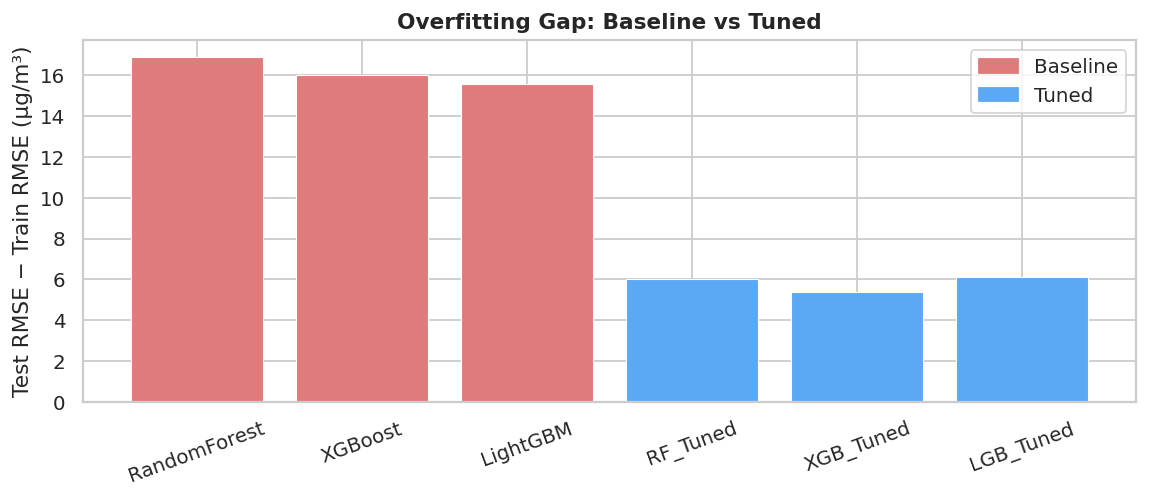

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tree_overfitting_gap.png


In [14]:
# Tính Train/Test RMSE gap để minh họa mức độ cải thiện overfitting
gap_rows = []

if not baseline_df.empty:
    for model in ["RandomForest", "XGBoost", "LightGBM"]:
        tr = baseline_df[(baseline_df.model == model) & (baseline_df.split == "train")]["RMSE"].values[0]
        te = baseline_df[(baseline_df.model == model) & (baseline_df.split == "test" )]["RMSE"].values[0]
        gap_rows.append({"model": model, "group": "Baseline", "train_rmse": tr, "test_rmse": te, "gap": te - tr})

for model in ["RF_Tuned", "XGB_Tuned", "LGB_Tuned"]:
    tr = tuned_metrics_df[(tuned_metrics_df.model == model) & (tuned_metrics_df.split == "train")]["RMSE"].values[0]
    te = tuned_metrics_df[(tuned_metrics_df.model == model) & (tuned_metrics_df.split == "test" )]["RMSE"].values[0]
    gap_rows.append({"model": model, "group": "Tuned", "train_rmse": tr, "test_rmse": te, "gap": te - tr})

gap_df = pd.DataFrame(gap_rows)
print("=== Overfitting Gap (Test RMSE − Train RMSE) ===")
display(gap_df[["model","group","train_rmse","test_rmse","gap"]].round(3))

# Bar chart gap
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#e07b7b" if g == "Baseline" else "#5ba8f5" for g in gap_df["group"]]
bars = ax.bar(gap_df["model"], gap_df["gap"], color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Test RMSE − Train RMSE (µg/m³)")
ax.set_title("Overfitting Gap: Baseline vs Tuned", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e07b7b", label="Baseline"), Patch(color="#5ba8f5", label="Tuned")])
plt.tight_layout()
out_gap = FIG_DIR / "tree_overfitting_gap.png"
fig.savefig(out_gap, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_gap.resolve())

## 11. Feature Importance — Mô hình Tốt nhất

Best model (test RMSE): XGB_Tuned


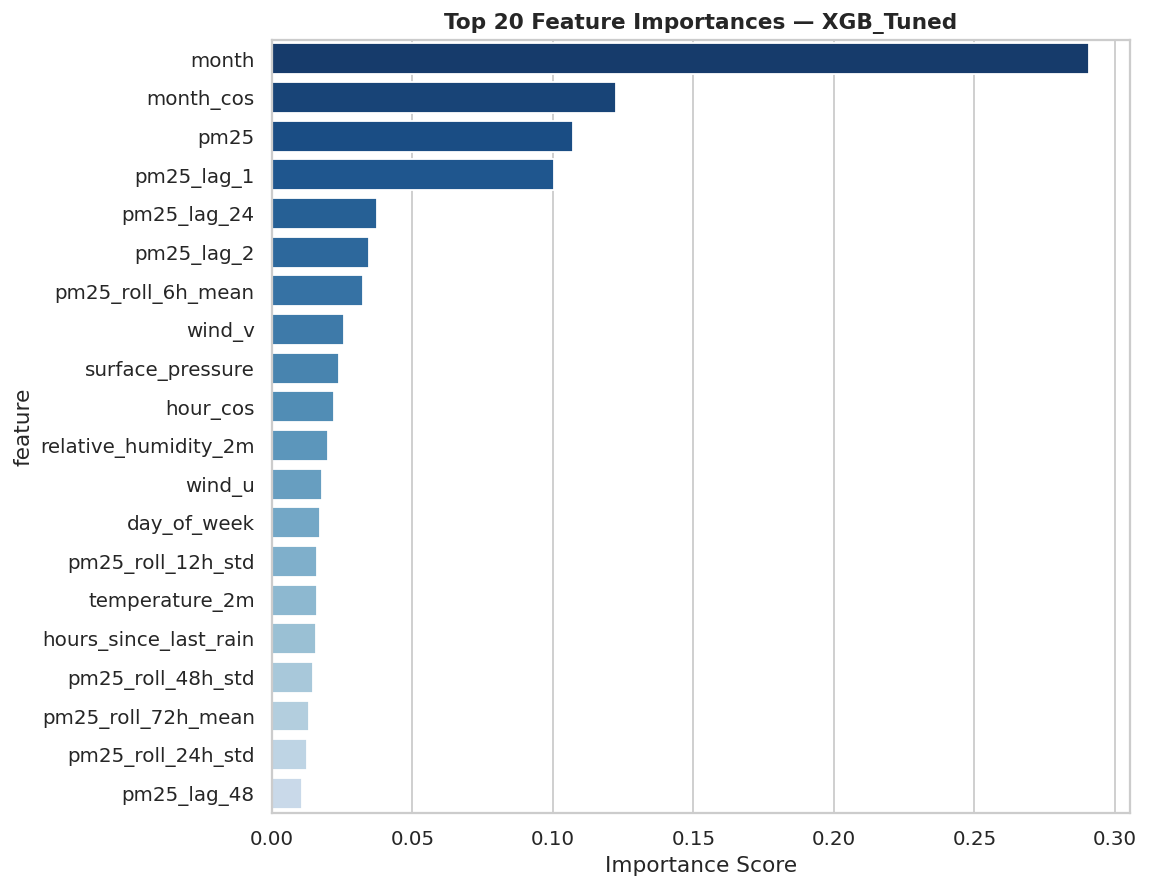

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tuned_tree_feature_importance_xgb_tuned.png


In [15]:
# Lấy mô hình có test RMSE thấp nhất
best_name = tuned_metrics_df[tuned_metrics_df.split == "test"].sort_values("RMSE").iloc[0]["model"]
best_model = tuned_models[best_name]
print(f"Best model (test RMSE): {best_name}")

feature_names = list(train_X.columns)
importances = best_model.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("Blues_r", len(imp_df))
sns.barplot(data=imp_df.head(20), x="importance", y="feature", palette=palette[:20], ax=ax)
ax.set_title(f"Top 20 Feature Importances — {best_name}", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
out_imp = FIG_DIR / f"tuned_tree_feature_importance_{best_name.lower()}.png"
fig.savefig(out_imp, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_imp.resolve())

## 12. Actual vs Predicted — Test Set

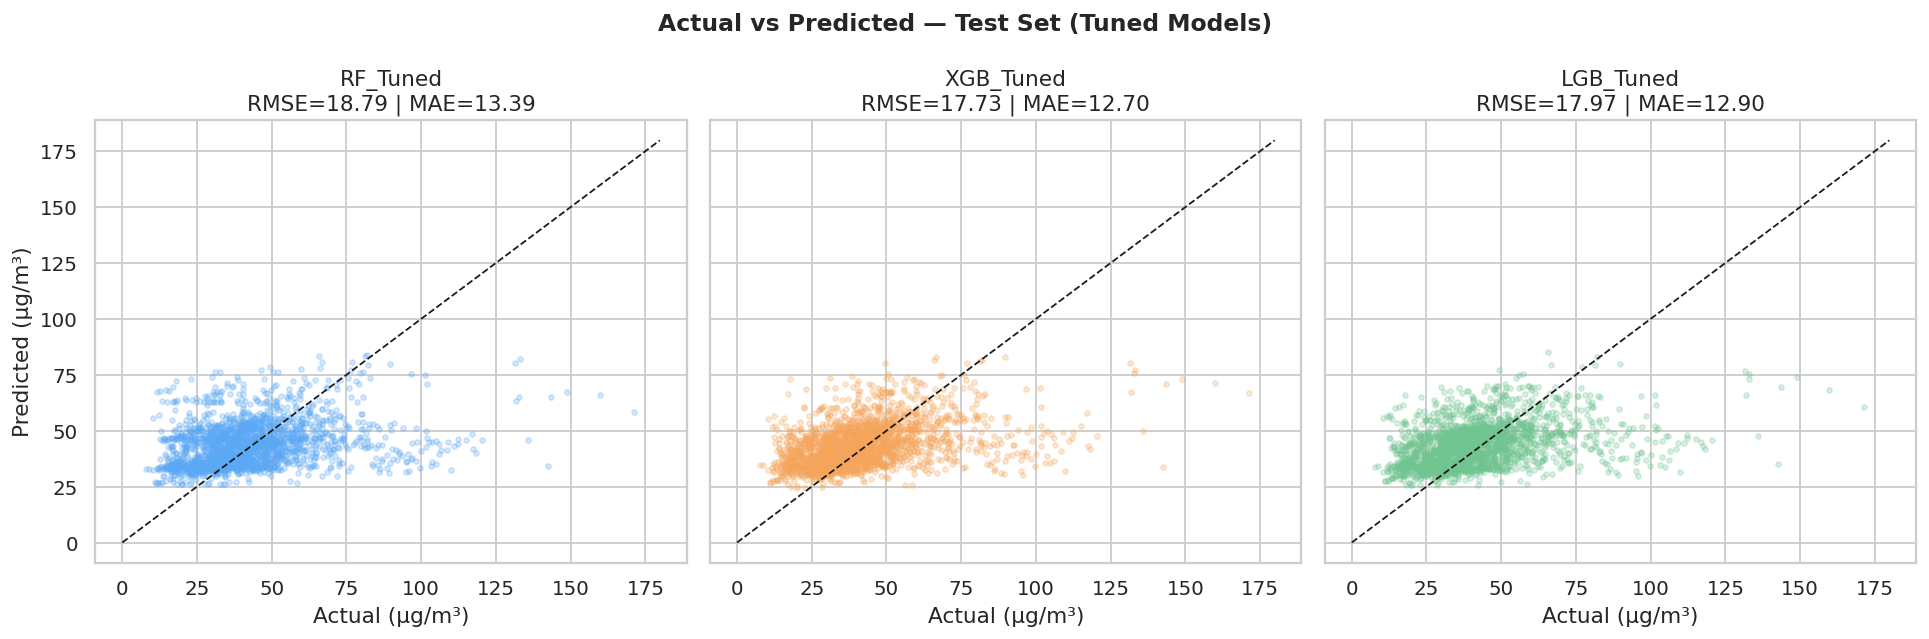

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tuned_tree_test_actual_vs_predicted.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
lim = float(test_y.max()) * 1.05
colors = ["#5ba8f5", "#f5a55b", "#70c490"]

for ax, (name, color) in zip(axes, zip(tuned_models.keys(), colors)):
    y_p = preds[name]["test"]
    m   = regression_metrics(test_y, y_p)
    ax.scatter(test_y, y_p, alpha=0.25, s=8, c=color)
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("Actual (µg/m³)")
    ax.set_title(f"{name}\nRMSE={m['RMSE']:.2f} | MAE={m['MAE']:.2f}")

axes[0].set_ylabel("Predicted (µg/m³)")
fig.suptitle("Actual vs Predicted — Test Set (Tuned Models)", fontweight="bold", fontsize=13)
plt.tight_layout()
out_sc = FIG_DIR / "tuned_tree_test_actual_vs_predicted.png"
fig.savefig(out_sc, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_sc.resolve())

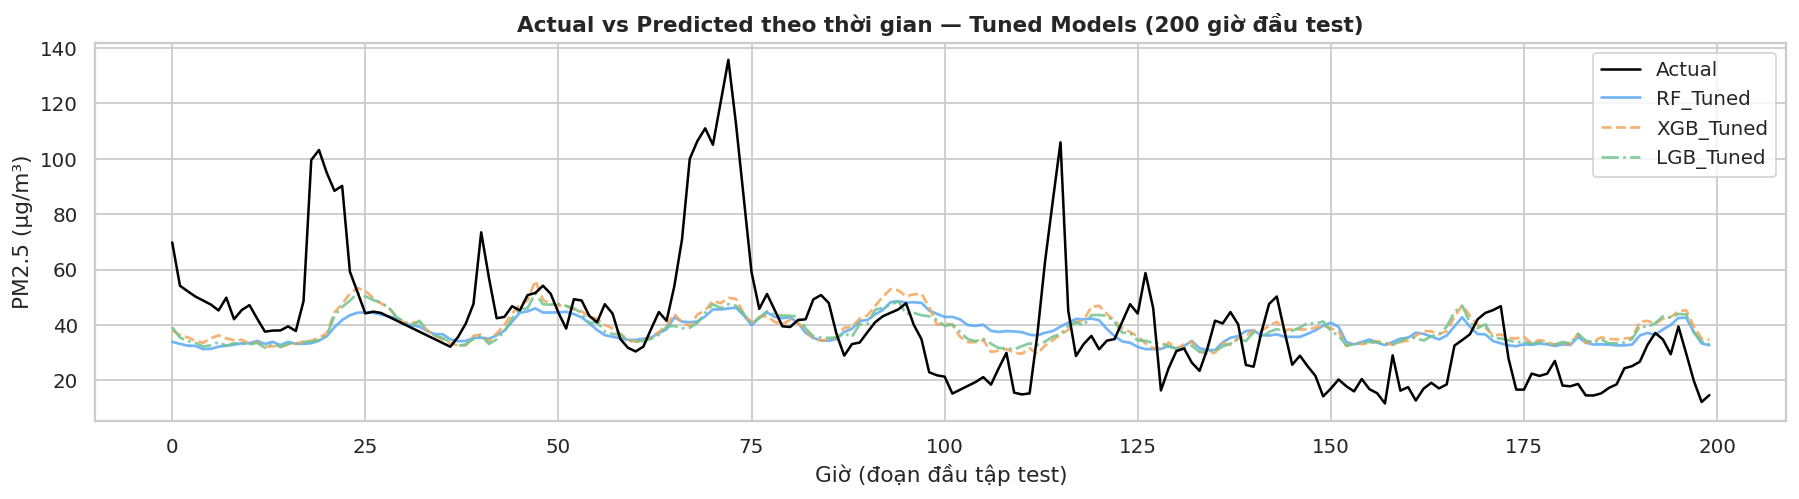

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tuned_tree_test_timeseries_subset.png


In [17]:
# Time-series subset (200 giờ đầu test)
k = min(200, len(test_dt))
idx = np.arange(k)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, test_y.iloc[:k].values, label="Actual", color="black", lw=1.4, zorder=5)
styles = ["-", "--", "-."]
colors_ts = ["#5ba8f5", "#f5a55b", "#70c490"]
for (name, _), ls, col in zip(tuned_models.items(), styles, colors_ts):
    ax.plot(idx, preds[name]["test"][:k], label=name, linestyle=ls, color=col, alpha=0.85)

ax.set_xlabel("Giờ (đoạn đầu tập test)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Actual vs Predicted theo thời gian — Tuned Models (200 giờ đầu test)", fontweight="bold")
ax.legend()
plt.tight_layout()
out_ts = FIG_DIR / "tuned_tree_test_timeseries_subset.png"
fig.savefig(out_ts, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_ts.resolve())

## 13. CV Results — Learning Curve mỗi Param Combination

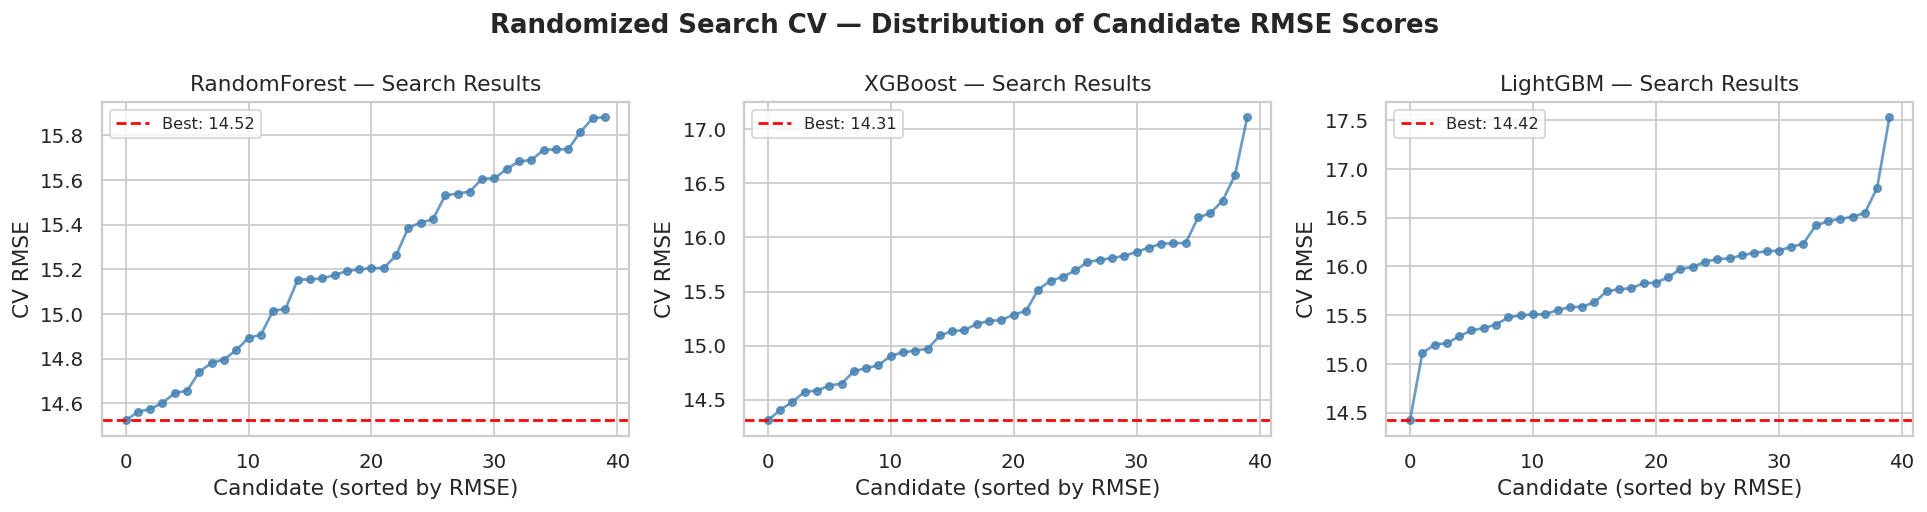

Đã lưu: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/figures/tuned_tree_cv_search_results.png


In [18]:
# Trực quan hóa CV scores của mỗi candidate (phân phối lần tìm kiếm)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, search) in zip(axes, [
    ("RandomForest", rf_search),
    ("XGBoost",      xgb_search),
    ("LightGBM",     lgb_search),
]):
    cv_scores = -search.cv_results_["mean_test_score"]
    sorted_scores = np.sort(cv_scores)
    ax.plot(sorted_scores, "o-", markersize=4, color="steelblue", alpha=0.8)
    ax.axhline(-search.best_score_, color="red", linestyle="--", lw=1.5, label=f"Best: {-search.best_score_:.2f}")
    ax.set_xlabel("Candidate (sorted by RMSE)")
    ax.set_ylabel("CV RMSE")
    ax.set_title(f"{name} — Search Results")
    ax.legend(fontsize=9)

fig.suptitle("Randomized Search CV — Distribution of Candidate RMSE Scores", fontweight="bold")
plt.tight_layout()
out_cv = FIG_DIR / "tuned_tree_cv_search_results.png"
fig.savefig(out_cv, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu:", out_cv.resolve())

## 14. Export — Predictions & Metrics

In [19]:
# ── 14.1 Export predictions dict (numpy arrays, raw µg/m³ scale)
preds_export = {}
for name in tuned_models:
    preds_export[name] = {
        "train": preds[name]["train"],
        "val":   preds[name]["val"],
        "test":  preds[name]["test"],
        "params": best_params_summary.get(name.replace("_Tuned", ""), {}),
    }

pkl_path = PRED_DIR / "tuned_tree_preds.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(preds_export, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Đã lưu predictions:", pkl_path.resolve())

Đã lưu predictions: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/predictions/tuned_tree_preds.pkl


In [20]:
# ── 14.2 Export metrics CSV
csv_path = PRED_DIR / "tuned_tree_metrics.csv"
tuned_metrics_df.to_csv(csv_path, index=False)
print("Đã lưu metrics:", csv_path.resolve())

# ── 14.3 Export best params JSON (human-readable)
json_path = PRED_DIR / "tuned_tree_best_params.json"
with open(json_path, "w") as f:
    # Chuyển numpy types sang Python native để json.dump không lỗi
    params_serializable = {
        k: {pk: (int(pv) if isinstance(pv, (np.integer,)) else
                 float(pv) if isinstance(pv, (np.floating,)) else pv)
            for pk, pv in v.items()}
        for k, v in best_params_summary.items()
    }
    json.dump(params_serializable, f, indent=2)
print("Đã lưu best params:", json_path.resolve())

Đã lưu metrics: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/predictions/tuned_tree_metrics.csv
Đã lưu best params: /home/duckk/dev/school/is403-ba/IS403_HCMC_Air_Quality/outputs/predictions/tuned_tree_best_params.json


## 15. Leaderboard Cuối — So sánh toàn diện

Tổng hợp **Baseline + Tuned** trên tập **Test** để đưa vào báo cáo.

In [21]:
final_rows = []

if not baseline_df.empty:
    for _, row in baseline_df[baseline_df.split == "test"].iterrows():
        final_rows.append({"Model": row["model"],  "Type": "Baseline",
                           "RMSE": row["RMSE"], "MAE": row["MAE"], "MAPE": row["MAPE"]})

for _, row in tuned_metrics_df[tuned_metrics_df.split == "test"].iterrows():
    final_rows.append({"Model": row["model"], "Type": "Tuned",
                       "RMSE": row["RMSE"], "MAE": row["MAE"], "MAPE": row["MAPE"]})

leaderboard = pd.DataFrame(final_rows).sort_values("RMSE").reset_index(drop=True)
leaderboard.index += 1  # Rank từ 1

print("=" * 65)
print("LEADERBOARD — TREE MODELS (Sorted by Test RMSE ↑)")
print("=" * 65)
display(leaderboard.round(3))

# Highlight best in each type
best_baseline = leaderboard[leaderboard.Type == "Baseline"].iloc[0]
best_tuned    = leaderboard[leaderboard.Type == "Tuned"].iloc[0]

print(f"\n Best Baseline: {best_baseline['Model']} — Test RMSE = {best_baseline['RMSE']:.3f}")
print(f" Best Tuned:    {best_tuned['Model']}    — Test RMSE = {best_tuned['RMSE']:.3f}")
if best_tuned["RMSE"] < best_baseline["RMSE"]:
    delta = best_baseline["RMSE"] - best_tuned["RMSE"]
    pct   = delta / best_baseline["RMSE"] * 100
    print(f" Cải thiện:    ↓ {delta:.3f} µg/m³ ({pct:.1f}%)")
else:
    print(" Không cải thiện được — cần xem xét lại không gian tìm kiếm.")

LEADERBOARD — TREE MODELS (Sorted by Test RMSE ↑)


,Model,Type,RMSE,MAE,MAPE
1,XGB_Tuned,Tuned,17.731,12.704,36.346
2,LGB_Tuned,Tuned,17.975,12.898,36.865
3,RF_Tuned,Tuned,18.794,13.388,38.718
4,XGBoost,Baseline,19.996,14.705,43.332
5,LightGBM,Baseline,20.378,14.892,43.464
6,RandomForest,Baseline,21.122,15.080,44.760



 Best Baseline: XGBoost — Test RMSE = 19.996
 Best Tuned:    XGB_Tuned    — Test RMSE = 17.731
 Cải thiện:    ↓ 2.264 µg/m³ (11.3%)
